# Análise Exploratória de Dados (EDA)
**Objetivo:** Geração de estatísticas descritivas, identificação de outliers e prototipagem visual das métricas de negócio.

### 1. Setup & Ingestão
Importação das bibliotecas de manipulação e visualização, e carregamento da base de dados tratada.

In [1]:
# 1. Setup e Ingestão
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

# Carregamento da base limpa gerada no ETL
caminho_tratada = '../data/base_tratada.csv'
df = pd.read_csv(caminho_tratada)

# Reconversão da data que pode ter sido lida como string no CSV
df['release_date'] = pd.to_datetime(df['release_date'])

### 2. Métricas de vendas e faturamento
Cálculo dos indicadores globais e regionais de performance comercial.

In [2]:
vendas_totais = df['total_sales'].sum()
media_vendas = df['total_sales'].mean()
recorde_vendas = df['total_sales'].max()
jogo_mais_vendido = df.loc[df['total_sales'].idxmax(), 'title']

print(f"Vendas Globais: {vendas_totais:.2f} milhões")
print(f"Média por Jogo: {media_vendas:.2f} milhões")
print(f"Recorde Histórico: {recorde_vendas:.2f} milhões ({jogo_mais_vendido})")

# Market Share Regional
colunas_regionais = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
market_share = (df[colunas_regionais].sum() / vendas_totais) * 100
print("\nMarket Share Regional (%):")
print(market_share.round(2))

Vendas Globais: 6605.91 milhões
Média por Jogo: 0.35 milhões
Recorde Histórico: 20.32 milhões (Grand Theft Auto V)

Market Share Regional (%):
na_sales       50.64
jp_sales       10.41
pal_sales      29.02
other_sales     9.86
dtype: float64


### 3. Identificação de outliers em vendas
Utilização do método IQR (Intervalo Interquartil) para isolar matematicamente jogos com vendas muito fora do padrão. 
*Exemplo simples:* Se o padrão de mercado é vender entre 0.5 e 2 milhões de cópias, um jogo que vende 30 milhões distorce a média geral e é classificado como outlier.

Quantidade de jogos outliers (sucessos anormais): 1963


,title,total_sales,console
0,Grand Theft Auto V,20.32,Ps3
1,Grand Theft Auto V,19.39,Ps4
2,Grand Theft Auto: Vice City,16.15,Ps2
3,Grand Theft Auto V,15.86,X360
4,Call of Duty: Black Ops 3,15.09,Ps4
5,Call of Duty: Modern Warfare 3,14.82,X360
6,Call of Duty: Black Ops,14.74,X360
7,Red Dead Redemption 2,13.94,Ps4
8,Call of Duty: Black Ops II,13.86,X360
9,Call of Duty: Black Ops II,13.80,Ps3


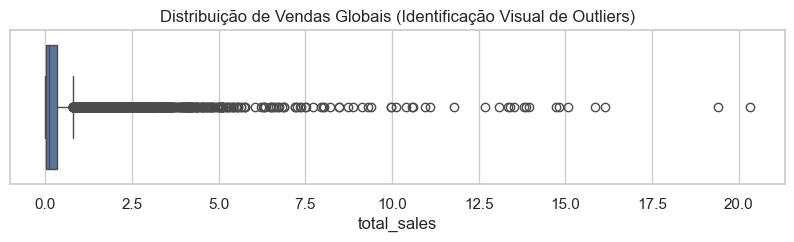

In [3]:
# Cálculo do IQR para Vendas Globais
Q1 = df['total_sales'].quantile(0.25)
Q3 = df['total_sales'].quantile(0.75)
IQR = Q3 - Q1

# Limite superior (jogos que venderam excepcionalmente bem)
limite_superior = Q3 + 1.5 * IQR

outliers = df[df['total_sales'] > limite_superior]
print(f"Quantidade de jogos outliers (sucessos anormais): {len(outliers)}")
display(outliers[['title', 'total_sales', 'console']].head(10))

# Boxplot para visualização dos outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['total_sales'])
plt.title('Distribuição de Vendas Globais (Identificação Visual de Outliers)')
plt.show()

### Tratamento de Outliers
Os títulos identificados acima não são erros de coleta, mas sim sucessos comerciais. Para preservar a integridade financeira das métricas globais e o faturamento das publicadoras, **estes registros não serão removidos do dataframe**. O tratamento da distorção visual causada por eles em gráficos de dispersão será implementado diretamente no dashboard através de um filtro condicional controlado pelo usuário.

### 4. Recepção e crítica
Cálculo de métricas focadas na qualidade percebida pela mídia especializada.

In [4]:
media_critica = df['critic_score'].mean()
jogos_aclamados = df[df['critic_score'] >= 9.0]
fracassos = df[df['critic_score'] <= 4.0]

# O uso de idxmax() em uma base filtrada (dropna) ignora jogos sem nota
jogo_mais_aclamado = df.loc[df['critic_score'].dropna().idxmax(), 'title']

print(f"Média da Crítica: {media_critica:.1f}/10")
print(f"Total de Jogos Aclamados (>9): {len(jogos_aclamados)}")
print(f"Total de Fracassos Críticos (<4): {len(fracassos)}")
print(f"Título Mais Aclamado: {jogo_mais_aclamado}")

Média da Crítica: 7.2/10
Total de Jogos Aclamados (>9): 612
Total de Fracassos Críticos (<4): 266
Título Mais Aclamado: Grand Theft Auto IV


### 5. Indústria e mercado
Agrupamentos para definir a rentabilidade e aclamação por gênero, console e publicadora.

In [5]:
print(f"Total de Jogos Lançados: {df['title'].nunique()}")
print(f"Consoles Ativos: {df['console'].nunique()}")
print(f"Publicadoras Diferentes: {df['publisher'].nunique()}")

# Agrupamentos de Rentabilidade
genero_rentavel = df.groupby('genre')['total_sales'].sum().idxmax()
pub_rentavel = df.groupby('publisher')['total_sales'].sum().idxmax()
console_rentavel = df.groupby('console')['total_sales'].sum().idxmax()

print(f"\nMais Rentáveis - Gênero: {genero_rentavel} | Publicadora: {pub_rentavel} | Console: {console_rentavel}")

# Agrupamentos de Aclamação (jogos com nota > 9)
genero_aclamado = jogos_aclamados['genre'].value_counts().idxmax()
pub_aclamada = jogos_aclamados['publisher'].value_counts().idxmax()
console_aclamado = jogos_aclamados['console'].value_counts().idxmax()

print(f"Mais Aclamados - Gênero: {genero_aclamado} | Publicadora: {pub_aclamada} | Console: {console_aclamado}")

Total de Jogos Lançados: 39798
Consoles Ativos: 81
Publicadoras Diferentes: 3383

Mais Rentáveis - Gênero: Sports | Publicadora: Activision | Console: Ps2
Mais Aclamados - Gênero: Shooter | Publicadora: Nintendo | Console: Pc


### 6. Prototipagem visual
Esboços em Matplotlib/Seaborn para validar lógicas matemáticas antes da construção interativa no Streamlit/Plotly.

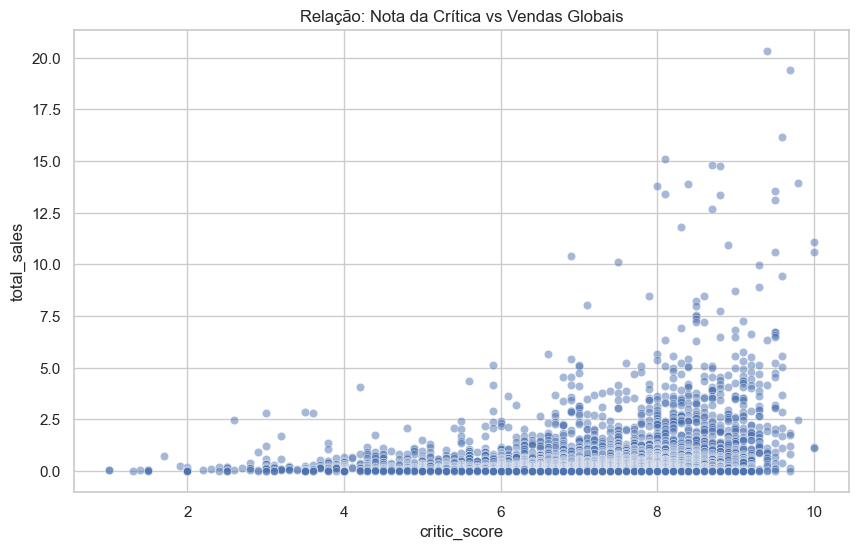

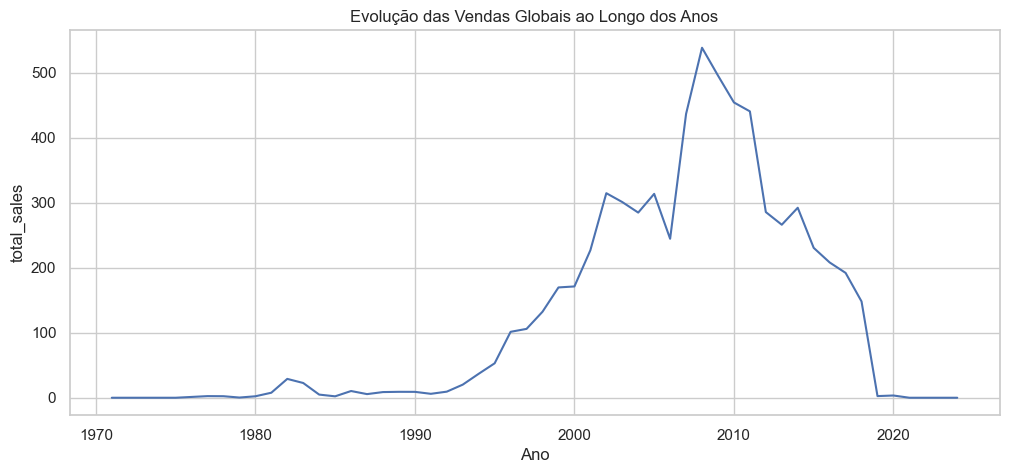

In [6]:
# 1. Relação Crítica vs Vendas (Dispersão)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='critic_score', y='total_sales', alpha=0.5)
plt.title('Relação: Nota da Crítica vs Vendas Globais')
plt.show()

# 2. Vendas ao longo do tempo (Evolução Geral)
# Extraímos o ano da data para agrupar as vendas
vendas_por_ano = df.groupby(df['release_date'].dt.year)['total_sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=vendas_por_ano, x='release_date', y='total_sales')
plt.title('Evolução das Vendas Globais ao Longo dos Anos')
plt.xlabel('Ano')
plt.show()

> ⚠️ **Anomalia crítica observada: Queda de vendas pós 2018**
> Ao analisar o gráfico de evolução temporal, nota-se um declínio abrupto no volume total de vendas a partir de 2018/2019, aproximando-se de zero nos anos mais recentes. 
> 
> **Fatores técnicos e limitações da base:**
> 1. **Viés de coleta:** Os dados históricos dependem fundamentalmente do rastreamento de mídias físicas em grandes varejistas. 
> 2. **Migração para o mercado digital:** A indústria passou por uma transição massiva para a distribuição digital (Steam, PlayStation Store, Xbox Marketplace). As publicadoras mantêm esses dados sob sigilo financeiro, o que impede a consolidação integral em datasets públicos gratuitos.
> 3. **Dados incompletos:** Os registros de lançamentos recentes (pós 2019) carecem de dados consolidados de vendas na fonte original, entrando na base com valores nulos ou zerados.
> 
> **Conclusão:** Este comportamento reflete uma **limitação metodológica da base de dados** e não uma recessão real do mercado de jogos. Para fins de tomada de decisão no dashboard, as análises de tendências temporais pós-2018 devem considerar este cenário.